# Poisson equation

This notebook demonstrates the solver for the spherical Poisson equation

$$\Delta V(x) = f = 4\pi G\,\varrho(x), \qquad x\in\mathbb{R}^3\setminus\{0\}$$

on either the half-line $(0,\infty)\times S^2$ or the exterior domain $[R,\infty)\times S^2$.

A spherical harmonic transform reduces the equation to one radial ODE per
degree $\ell$, which is solved in closed form by the Green's function.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from torch_harmonics.examples import RadialPoissonSolver

# Poisson on the half-line
First we start with Poisson on the half-line $(0,\infty)\times S^2$ and set up a `RadialPoissonSolver` on a 256 x 64 x 128 grid (nr, nlat, nlon) with a legendre-gauss grid on $S^2$ and a geometric grid in the radial direction. Compared to the ShallowWaterSolver we don't have timestepping here and only map a forcing $f$ to a solution $u$.

In [2]:
nlat, nlon, nr = 64, 128, 256
rmin, rmax = 0.1, 1000.0
grid = "legendre-gauss"

solver = RadialPoissonSolver(nlat, nlon, nr, rmin, rmax, grid=grid, domain="half-line")

## Radial Grid
The radial grid is geometric $r_k = r_0 q^k$ with $k = 0, . . . , Nr − 1$, so it is uniform in $x = \log r$. This leads to more grid points near the origin and only a sparse field near the outer boundary. The plot below compares both coordinate types.

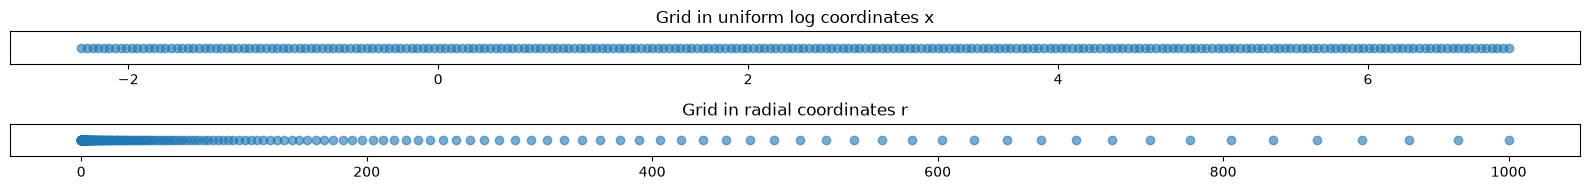

In [3]:
def plot_radial_grid(r, x, rname="r"):
    fig, ax = plt.subplots(2, 1, figsize=(16, 2))
    ax[0].scatter(x, np.zeros_like(x), alpha=0.6)
    ax[1].scatter(r, np.zeros_like(r), alpha=0.6)

    ax[0].set_yticks([])
    ax[1].set_yticks([])

    ax[0].set_title("Grid in uniform log coordinates x")
    ax[1].set_title(f"Grid in radial coordinates {rname}")

    fig.tight_layout()
    plt.show()

r = solver.r
x = solver.x

plot_radial_grid(r, x)

## Forcing Function
For the spherical Poisson equation we map a forcing $f$ to a solution $u$. The forcing or source can be generated by `solver.random_source(..)` and consists of multiple blobs. Each blob is a random band-limited angular field of degrees $\ell \le$ `l_src`, enveloped by a compact radial bump of random width. An `nblobs` number of blobs at random radii are summed to build the full forcing field.

The plots below show a forcing example as a meridional slice (lat and r) and the $S^2$ slice at a selected radius `k` which is also marked as a dashed line in the other two plots.

In [4]:
f = solver.random_source(nblobs=8, l_src=8, margin=0.12, width=(0.03, 0.1))
print(f"source: {tuple(f.shape)}")

source: (256, 64, 128)


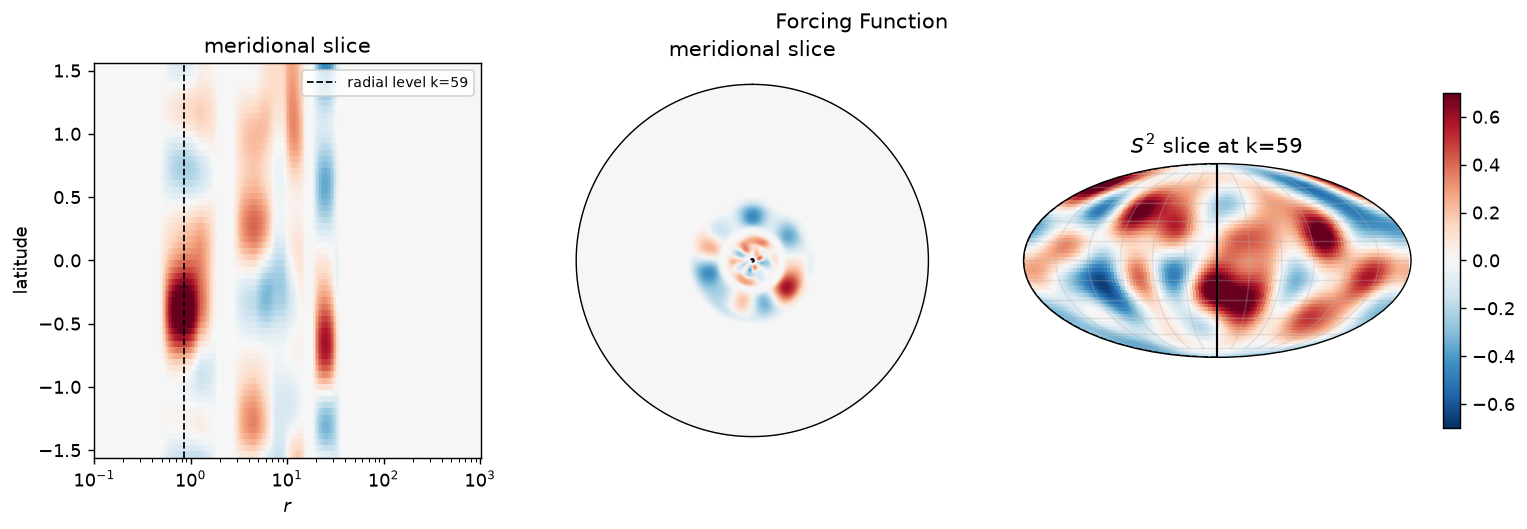

In [5]:
# plot of forcing function
k = f.abs().amax(dim=(-1, -2)).argmax().item()
ilon = solver.nlon // 2          # maps to mollweide x = 0, the visible centre
kw = dict(vmin=-0.7, vmax=0.7, colorbar=False, cmap="RdBu_r")

fig = plt.figure(figsize=(16, 4), dpi=128)
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1])
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2], projection="mollweide")

solver.plot_meridional(f, ax=ax1, ilon=ilon, title="meridional slice", projection="log", **kw)
ax1.axvline(solver.r[k].cpu(), c='k', ls='--', lw=1)
ax1.legend(["radial level k=" + str(k)], loc="upper right", fontsize=8)

solver.plot_meridional(f, ax=ax2, ilon=ilon, title="meridional slice", projection="polar", rmax=100, **kw)
ax2.add_patch(plt.Circle((0, 0), solver.r[k].item(), fill=False, ec='k', ls='--', lw=1))

im = solver.plot_sphere(f[k], ax=ax3, title=r"$S^2$ slice at k=" + str(k), **kw)
x0 = solver.lons[ilon].item() - np.pi
ax3.vlines(x0, -np.pi/2, np.pi/2, colors='k', ls='-', lw=1.2)
ax3.vlines(np.remainder(x0 + 2*np.pi, 2*np.pi) - np.pi, -np.pi/2, np.pi/2, colors='k', ls='--', lw=1)

fig.suptitle("Forcing Function")
fig.colorbar(im, ax=[ax1, ax2, ax3], shrink=0.85, pad=0.02)
plt.show()


## Solution
To solve spherical Poisson we use the Spherical Harmonic Transform to reduce the equation to one radial ODE per degree $\ell$:
$$u_{\ell m}'' + \frac{2}{r} u_{\ell m}' - \frac{\ell(\ell+1)}{r^2} u_{\ell m} = f_{\ell m}(r)$$

For each degree we solve with the Green's function
$$u_{\ell m}(r) = -\frac{1}{2\ell+1}\int y_{\rm in}(r_<) r_>^{-(\ell+1)} f_{\ell m}(s) s^2 ds$$

where $r_< = \min(r,s)$, $r_> = \max(r,s)$, and $y_{\rm in} = r^\ell$ on the half-line or $y_{\rm in} = r^\ell - R^{2\ell+1} r^{-(\ell+1)}$ on the exterior. This gives the exact solution in one step and is discretized via quadrature to one matrix-vector product per degree $\ell$.

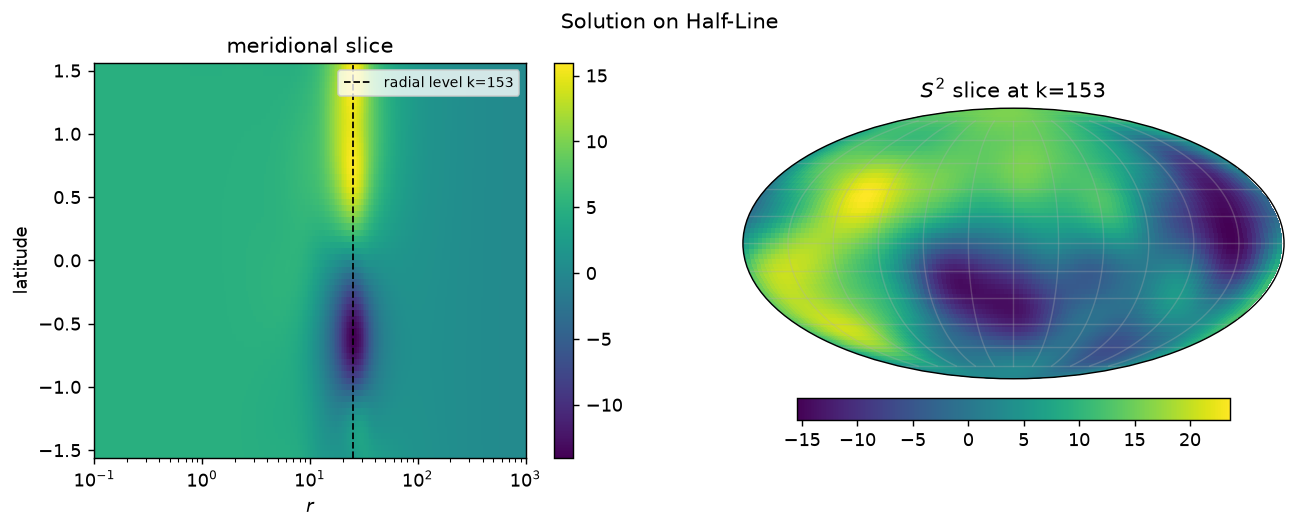

In [6]:
# solve poisson
with torch.no_grad():
    u = solver.solve(f)

# plot solution
k = u.abs().amax(dim=(-1, -2)).argmax().item()

fig = plt.figure(figsize=(12, 4), dpi=128)
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1])
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], projection="mollweide")

solver.plot_meridional(u, ax=ax1, ilon=ilon, title="meridional slice", projection="log")
ax1.axvline(solver.r[k].cpu(), c='k', ls='--', lw=1)
ax1.legend(["radial level k=" + str(k)], loc="upper right", fontsize=8)

im = solver.plot_sphere(u[k], ax=ax2, title=r"$S^2$ slice at k=" + str(k))

fig.suptitle("Solution on Half-Line")
plt.show()

# Poisson on the Exterior
With the `RadialPoissonSolver` we can also solve Poisson on the exterior domain $[R,\infty)\times S^2$. For that we map the exterior to the half-line via a radial shift $\rho = (r − R)$. In this setting we also have to determine a Dirichlet boundary condition at $r=R$. That could be homogeneous or a random field (inhomogeneous).


innermost grid node: r = 1.010000  (rho = 1.00e-02)


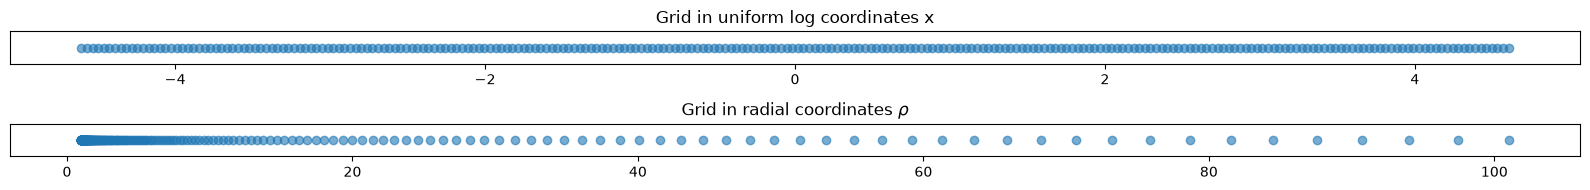

In [7]:
rhomin, rhomax = 1e-2, 1e2
R = 1
ext = RadialPoissonSolver(nlat, nlon, nr, rhomin, rhomax, grid=grid, R=R, domain="exterior")

print(f"\ninnermost grid node: r = {ext.r[0]:.6f}  (rho = {ext.r[0] - R:.2e})")
plot_radial_grid(ext.r, ext.x, rname=r"$\rho$")

In [8]:
# generate source and boundary data
f = ext.random_source(nblobs=8, l_src=8, margin=0.12)
v0 = ext.random_boundary_data(l_src=8)

# solve poisson with boundary
with torch.no_grad():
    u = ext.solve(f, v0)

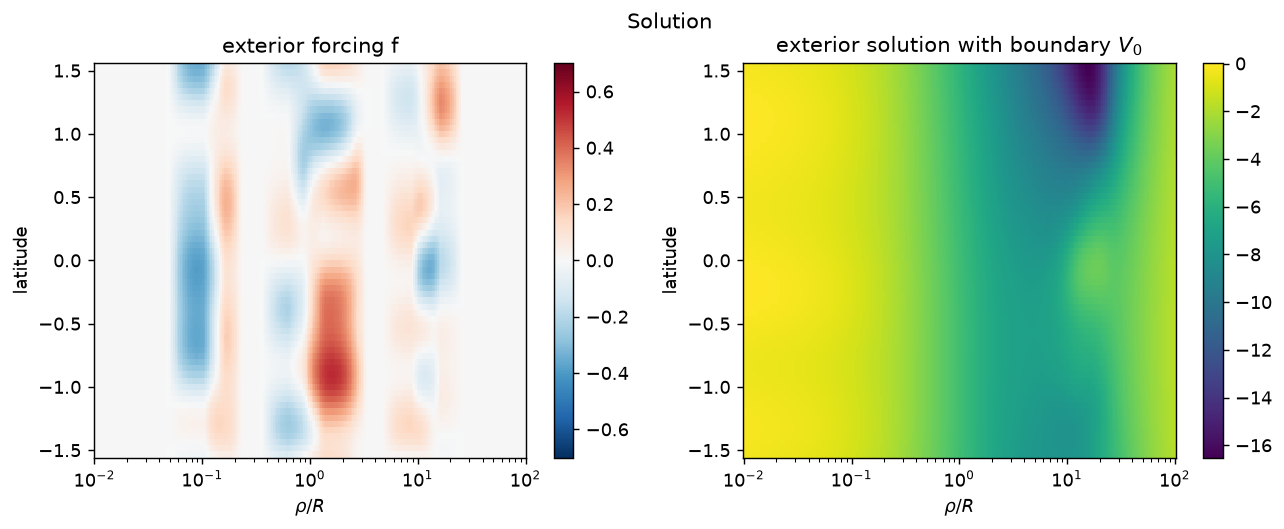

In [9]:
# plot solution
fig = plt.figure(figsize=(12, 4), dpi=128)
ax1, ax2 = fig.subplots(1, 2, width_ratios=[1, 1])

ext.plot_meridional(f, ax=ax1, title="exterior forcing f", projection="log", cmap="RdBu_r", vmin=-0.7, vmax=0.7)
ext.plot_meridional(u, ax=ax2, title=r"exterior solution with boundary $V_0$", projection="log")

fig.suptitle("Solution")
plt.show()

# Poisson Dataset
To train an Operator or any other network on the Poisson Equation, we can use `PoissonDataset` similar to the `PdeDataset` for PlanetSWE.

In [10]:
from torch_harmonics.examples import PoissonDataset

ds = PoissonDataset(num_examples=512, normalize=True)

inp, tar = ds[0]
print(f"input: {tuple(inp.shape)}, target: {tuple(tar.shape)}")

input: (256, 64, 128), target: (256, 64, 128)


# Mellin Transformation

TODO small intro for Mellin transf

In [97]:
from torch_harmonics import MellinTransform, InverseMellinTransform, RealSHT, InverseRealSHT

# solver for half-line poisson equation
# radial transformation
wmax = None
mel = MellinTransform(solver.nr, solver.rmin, solver.rmax, wmax=wmax, domain=solver.domain, dim=-3)
imel = InverseMellinTransform(solver.nr, solver.rmin, solver.rmax, wmax=wmax, domain=solver.domain, dim=-3)

# angular transformation
sht = RealSHT(solver.nlat, solver.nlon, grid=solver.grid)
isht = InverseRealSHT(solver.nlat, solver.nlon, grid=solver.grid)

# signal from half-line poisson solver
signal = solver.random_source(nblobs=8, l_src=8, margin=0.12, width=(0.03, 0.1))

# transformation
coeff = mel(sht(signal))
recon = isht(imel(coeff))

print(f"signal: {tuple(signal.shape)}, coeff: {tuple(coeff.shape)}, recon: {tuple(recon.shape)}")

signal: (256, 64, 128), coeff: (256, 64, 64), recon: (256, 64, 128)


TODO plot the spectral energy

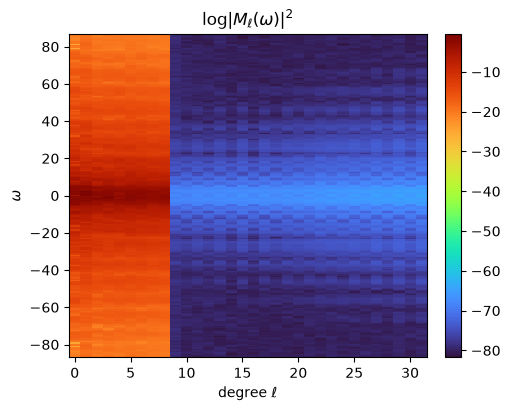

In [94]:
# energy summed over m (rotation invariant and convolution acts on (omega, l))
E = coeff.abs().pow(2).sum(-1)
E = torch.fft.fftshift(E, dim=0)
omega = torch.fft.fftshift(mel.omega)

lmax = 32
fig, ax = plt.subplots(figsize=(5, 4), layout="constrained")
im = ax.pcolormesh(torch.arange(lmax), omega, torch.log(E[:, :lmax]), cmap="turbo")
ax.set_xlabel(r"degree $\ell$")
ax.set_ylabel(r"$\omega$")
ax.set_title(r"$\log |M_{\ell}(\omega)|^2$")
fig.colorbar(im, ax=ax)
plt.show()

TODO now show reconstruction

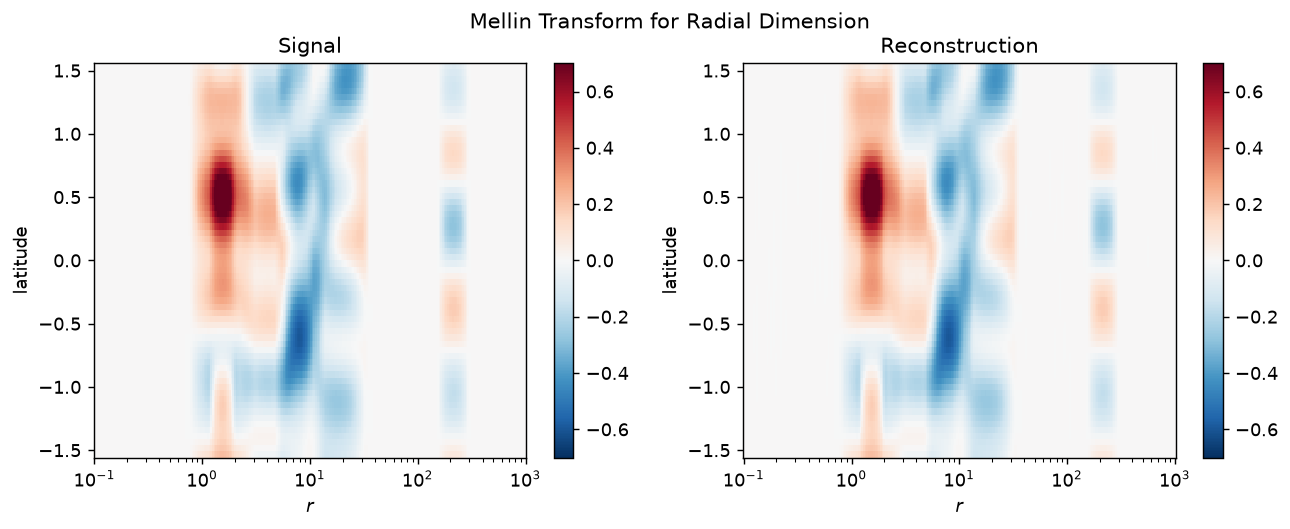

In [98]:
# plot reconstruction
fig = plt.figure(figsize=(12, 4), dpi=128)
ax1, ax2 = fig.subplots(1, 2, width_ratios=[1, 1])

solver.plot_meridional(signal, ax=ax1, title="Signal", projection="log", cmap="RdBu_r", vmin=-0.7, vmax=0.7)
solver.plot_meridional(recon, ax=ax2, title=r"Reconstruction", projection="log", cmap="RdBu_r", vmin=-0.7, vmax=0.7)

fig.suptitle("Mellin Transform for Radial Dimension")
plt.show()

TODO reconstruction error

error: 5.01e-13 (max abs)


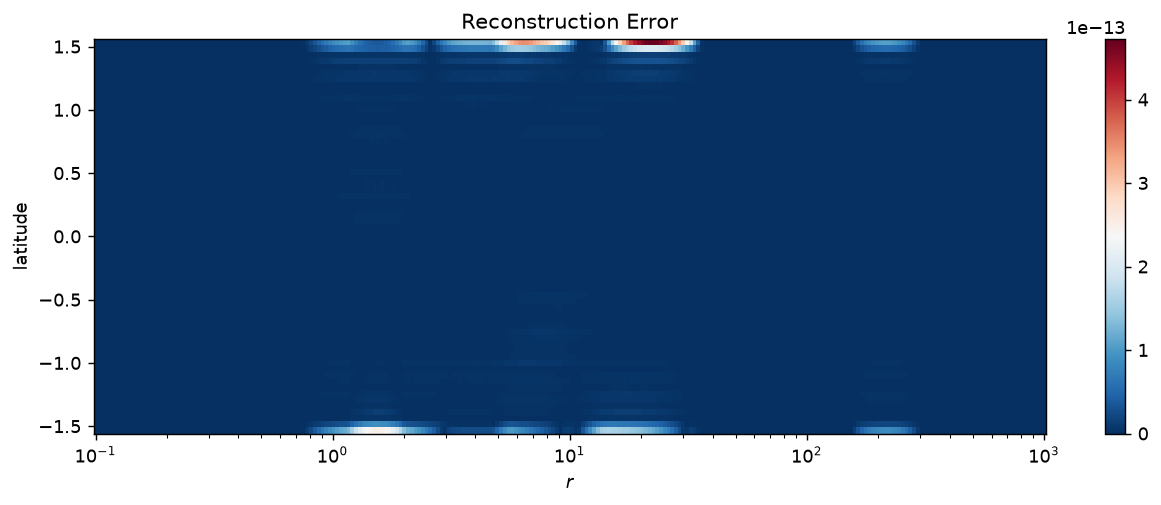

In [99]:
ax = plt.figure(figsize=(12, 4), dpi=128).subplots(1, 1)

err = (recon - signal).abs()
print(f"error: {err.abs().amax().item():.2e} (max abs)")
solver.plot_meridional(err, ax=ax, title="Reconstruction Error", projection="log", cmap="RdBu_r")
plt.show()

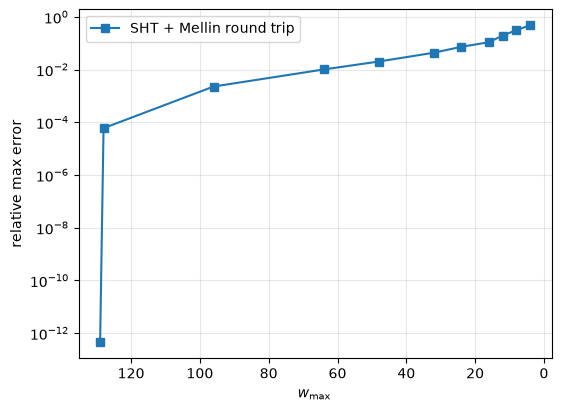

In [103]:
wmaxs = [129, 128, 96, 64, 48, 32, 24, 16, 12, 8, 4]
alm = sht(f)
err_mel, err_all = [], []
for w in wmaxs:
    m = MellinTransform(solver.nr, solver.rmin, solver.rmax, wmax=w, domain=solver.domain, R=solver.R, dim=-3)
    im_ = InverseMellinTransform(solver.nr, solver.rmin, solver.rmax, wmax=w, domain=solver.domain, R=solver.R, dim=-3)
    rt = im_(m(alm))
    err_all.append((isht(rt) - f).abs().max().item() / f.abs().max().item())

fig, ax = plt.subplots(figsize=(5.5, 4), layout="constrained")
ax.semilogy(wmaxs, err_all, "s-", label="SHT + Mellin round trip")
ax.invert_xaxis()
ax.set_xlabel(r"$w_{\max}$"); ax.set_ylabel("relative max error")
ax.legend(); ax.grid(alpha=0.3)
plt.show()